In [12]:
import scipy.io
import numpy as np
from collections import Counter
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
# Convert networkx graphs to PyTorch Geometric Data objects
import torch.nn.functional as F
from torch_geometric.nn import global_mean_pool, GCNConv, GATConv, SAGEConv, global_add_pool
import torch.nn as nn
import torch
import torch.nn as nn
import torch_geometric
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, ChebConv, SAGEConv, global_mean_pool
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GroupKFold,LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats
import networkx as nx
import mne
import numpy as np
from mne_connectivity import spectral_connectivity_epochs
# import bct

In [3]:
mat_data = scipy.io.loadmat('/Users/siddharth/Documents/Brainconnectivity/ranked_features.mat')
ranked_features = mat_data['ranked_features']

In [4]:
ranked_features.shape

(1152, 22, 17)

In [6]:
ranked_features_5 = ranked_features[:,:,:10]

In [7]:
ranked_features_5.shape

(1152, 22, 10)

In [8]:
num_samples,num_channels,num_features = ranked_features_5.shape

In [9]:
ranked_features_5_reshaped = ranked_features_5.reshape(num_samples, num_channels * num_features)

In [10]:
import numpy as np
import mne
import h5py
from scipy.stats import spearmanr

def extract_filtered_eeg(i):
    """ Load, preprocess EEG data, and extract connectivity features. """

    raw = mne.io.read_raw_gdf(f'/Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A0{i}T.gdf',
                              eog=['EOG-left', 'EOG-central', 'EOG-right'], preload=True)
    raw.drop_channels(['EOG-left', 'EOG-central', 'EOG-right'])
    raw.set_eeg_reference()

    channel_rename_dict = {
        'EEG-Fz': 'Fz', 'EEG-0': 'FC3', 'EEG-1': 'FC1', 'EEG-2': 'FCz', 'EEG-3': 'FC2', 'EEG-4': 'FC4',
        'EEG-5': 'C5', 'EEG-C3': 'C3', 'EEG-6': 'C1', 'EEG-Cz': 'Cz', 'EEG-7': 'C2', 'EEG-C4': 'C4',
        'EEG-8': 'C6', 'EEG-9': 'CP3', 'EEG-10': 'CP1', 'EEG-11': 'CPz', 'EEG-12': 'CP2', 'EEG-13': 'CP4',
        'EEG-14': 'P1', 'EEG-Pz': 'Pz', 'EEG-15': 'P2', 'EEG-16': 'POz'
    }
    raw.rename_channels(channel_rename_dict)
    raw.set_montage(mne.channels.make_standard_montage('standard_1020'))

    events, event_id = mne.events_from_annotations(raw)
    epoch = mne.Epochs(raw, events, event_id={'769': 7, '770': 8}, tmin=-1.5, tmax=6, preload=True)

    labels = epoch.events[:, -1] - 7
    labels = np.array(labels)  # Ensure labels are NumPy array
    epoch.apply_baseline((-1.5, 0.0))
    file_path = f'/Users/siddharth/Documents/Brainconnectivity/filtered_Artifacts_removed/filt_PreProc_EEG_ICA_filt_sub{i}.mat'
    
    def recursive_get_data(group, file):
        """ Recursively extract HDF5 data. """
        data = {}
        for key in group:
            item = group[key]
            if isinstance(item, h5py.Group):
                data[key] = recursive_get_data(item, file)
            elif isinstance(item, h5py.Dataset):
                data[key] = item[:]
            elif isinstance(item, h5py.Reference):
                ref_obj = file[item]
                if isinstance(ref_obj, h5py.Dataset):
                    data[key] = ref_obj[:]
                elif isinstance(ref_obj, h5py.Group):
                    data[key] = recursive_get_data(ref_obj, file)
        return data

    with h5py.File(file_path, 'r') as f:
        all_data = recursive_get_data(f, f)

    eeg_data = []
    for key in all_data.get('#refs#', {}):
        ref_group = all_data['#refs#'][key]
        if ref_group.shape[0] == 751:
            eeg_data.append(ref_group)

    eeg_data = np.stack(eeg_data, axis=0).reshape(144, 22, 751)  # Adjust shape if needed

    return eeg_data, labels, epoch['769'].average()

In [11]:
import numpy as np

eeg_data = []
labels = []

for i in range(2, 10):
    i = 8 
    data, label, info = extract_filtered_eeg(i)
    
    eeg_data.append(data)  # Append EEG data for the current subject
    labels.append(label)    # Append labels for the current subject

eeg_data = np.array(eeg_data)  # Shape: (num_subjects, num_trials, num_channels, num_datapoints)
labels = np.array(labels)      # Shape: (num_subjects, num_trials)


eeg_data = eeg_data.reshape(-1, 22, eeg_data.shape[-1])  # Shape: (num_trials, num_channels, feature_dim)
labels = labels.reshape(-1)  # Shape: (num_trials, num_channels, feature_dim)

print("EEG Data Shape:", eeg_data.shape)  # Expected shape: (num_subjects, num_trials, num_channels, num_datapoints)
print("Labels Shape:", labels.shape)      # Expected shape: (num_subjects, num_trials)

Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A08T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Reading 0 ... 675269  =      0.000 ...  2701.076 secs...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A08T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 675269  =      

/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A08T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 675269  =      0.000 ...  2701.076 secs...


...

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A08T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 675269  =      0.000 ...  2701.076 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A08T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 675269  =      0.000 ...  2701.076 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
EEG Data Shape: (1152, 22, 751)
Labels Shape: (1152,)


In [14]:
eeg_data_0 = eeg_data[labels == 0]
eeg_data_1 = eeg_data[labels == 1]

In [15]:
# Define EEG channel names
ch_names = [f'EEG{i+1}' for i in range(22)]
info = mne.create_info(ch_names=ch_names, sfreq=250, ch_types='eeg')

# Create MNE Epochs objects
epochs_0 = mne.EpochsArray(eeg_data_0, info)
epochs_1 = mne.EpochsArray(eeg_data_1, info)

# Define frequency range
fmin, fmax = 0.5, 48.0  

# Compute connectivity separately for each trial
n_trials = len(epochs_0)

# Initialize array to store per-trial connectivity
connectivity_0_trials = []
connectivity_1_trials = []

for trial in range(n_trials):
    con_0 = spectral_connectivity_epochs(
        epochs_0[trial],  # Process one trial at a time
        method='imcoh',       
        mode='multitaper',    
        sfreq=250,
        fmin=fmin,
        fmax=fmax,
        faverage=True,       
        mt_bandwidth=4.0,    
        n_jobs=-1
    ).get_data()
    
    con_1 = spectral_connectivity_epochs(
        epochs_1[trial],  # Process one trial at a time
        method='imcoh',       
        mode='multitaper',    
        sfreq=250,
        fmin=fmin,
        fmax=fmax,
        faverage=True,       
        mt_bandwidth=4.0,    
        n_jobs=-1
    ).get_data()

    connectivity_0_trials.append(con_0)
    connectivity_1_trials.append(con_1)

# Convert list to NumPy arrays
connectivity_0_trials = np.array(connectivity_0_trials)  # Shape: (72, 484, 1)
connectivity_1_trials = np.array(connectivity_1_trials)  # Shape: (72, 484, 1)

# Print the shapes
print("Connectivity_0 shape:", connectivity_0_trials.shape)
print("Connectivity_1 shape:", connectivity_1_trials.shape)

Not setting metadata
576 matching events found
No baseline correction applied


0 projection items activated
Not setting metadata
576 matching events found
No baseline correction applied
0 projection items activated
Connectivity computation...
only using indices for lower-triangular matrix
    computing connectivity for 231 connections
    using t=0.000s..3.000s for estimation (751 points)
    frequencies: 0.7Hz..47.9Hz (143 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 11 DPSS windows
    the following metrics will be computed: Imaginary Coherence
    computing cross-spectral density for epochs 1..1


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_50602/720706719.py:20: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not modified.
  con_0 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_50602/720706719.py:20: RuntimeWarning: fmin=0.500 Hz corresponds to 1.502 < 5 cycles based on the epoch length 3.004 sec, need at least 10.000 sec epochs or fmin=1.664. Spectrum estimate will be unreliable.
  con_0 = spectral_connectivity_epochs(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


    assembling connectivity matrix
[Connectivity computation done]
Connectivity computation...
only using indices for lower-triangular matrix
    computing connectivity for 231 connections
    using t=0.000s..3.000s for estimation (751 points)
    frequencies: 0.7Hz..47.9Hz (143 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 11 DPSS windows
    the following metrics will be computed: Imaginary Coherence
    computing cross-spectral density for epochs 1..1


/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_50602/720706719.py:32: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not modified.
  con_1 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_50602/720706719.py:32: RuntimeWarning: fmin=0.500 Hz corresponds to 1.502 < 5 cycles based on the epoch length 3.004 sec, need at least 10.000 sec epochs or fmin=1.664. Spectrum estimate will be unreliable.
  con_1 = spectral_connectivity_epochs(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


...

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_50602/720706719.py:32: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not modified.
  con_1 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_50602/720706719.py:32: RuntimeWarning: fmin=0.500 Hz corresponds to 1.502 < 5 cycles based on the epoch length 3.004 sec, need at least 10.000 sec epochs or fmin=1.664. Spectrum estimate will be unreliable.
  con_1 = spectral_connectivity_epochs(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_50602/720706719.py:20: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not modified.
  con_0 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5x6v

    Using multitaper spectrum estimation with 11 DPSS windows
    the following metrics will be computed: Imaginary Coherence
    computing cross-spectral density for epochs 1..1
    assembling connectivity matrix
[Connectivity computation done]
Connectivity computation...
only using indices for lower-triangular matrix
    computing connectivity for 231 connections
    using t=0.000s..3.000s for estimation (751 points)
    frequencies: 0.7Hz..47.9Hz (143 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 11 DPSS windows
    the following metrics will be computed: Imaginary Coherence
    computing cross-spectral density for epochs 1..1
    assembling connectivity matrix
[Connectivity computation done]
Connectivity computation...
only using indices for lower-triangular matrix
    computing connectivity for 231 connections
    using t=0.000s..3.000s for estimation (751 points)
    frequencies: 0.7Hz..47.9Hz (143 points)
    connect

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_50602/720706719.py:32: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not modified.
  con_1 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_50602/720706719.py:32: RuntimeWarning: fmin=0.500 Hz corresponds to 1.502 < 5 cycles based on the epoch length 3.004 sec, need at least 10.000 sec epochs or fmin=1.664. Spectrum estimate will be unreliable.
  con_1 = spectral_connectivity_epochs(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_50602/720706719.py:20: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not 

Connectivity computation...
only using indices for lower-triangular matrix
    computing connectivity for 231 connections
    using t=0.000s..3.000s for estimation (751 points)
    frequencies: 0.7Hz..47.9Hz (143 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 11 DPSS windows
    the following metrics will be computed: Imaginary Coherence
    computing cross-spectral density for epochs 1..1
    assembling connectivity matrix
[Connectivity computation done]
Connectivity computation...
only using indices for lower-triangular matrix
    computing connectivity for 231 connections
    using t=0.000s..3.000s for estimation (751 points)
    frequencies: 0.7Hz..47.9Hz (143 points)
    connectivity scores will be averaged for each band
    Using multitaper spectrum estimation with 11 DPSS windows
    the following metrics will be computed: Imaginary Coherence
    computing cross-spectral density for epochs 1..1
    assembling connecti

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_50602/720706719.py:20: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not modified.
  con_0 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_50602/720706719.py:20: RuntimeWarning: fmin=0.500 Hz corresponds to 1.502 < 5 cycles based on the epoch length 3.004 sec, need at least 10.000 sec epochs or fmin=1.664. Spectrum estimate will be unreliable.
  con_0 = spectral_connectivity_epochs(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_50602/720706719.py:32: RuntimeWarning: There were no Annotations stored in <EpochsArray | 1 events (all good), 0 – 3 s (baseline off), ~151 kB, data loaded,
 '1': 1>, so metadata was not modified.
  con_1 = spectral_connectivity_epochs(
/var/folders/dh/nfwywq5x6v

In [16]:
connectivity_0_trials = connectivity_0_trials.reshape(576,22,22)
connectivity_1_trials = connectivity_1_trials.reshape(576,22,22)

In [17]:
features = np.array(ranked_features_5)

In [18]:
labels = labels.reshape(-1)

In [19]:
import numpy as np
import networkx as nx
import scipy.io
from scipy import stats

def create_graphs_with_edge_indicator(features, labels, connectivity_0_trials, connectivity_1_trials):
    graphs = []
    unique_labels = np.unique(labels)

    # Combine all connectivity trials
    all_connectivity = np.concatenate([connectivity_0_trials, connectivity_1_trials], axis=0)
    all_labels = np.concatenate([np.zeros(connectivity_0_trials.shape[0]), np.ones(connectivity_1_trials.shape[0])])

    num_nodes = connectivity_0_trials.shape[1]  # Should be 22
    # Construct graphs for each trial
    for trial_idx in range(all_connectivity.shape[0]):
        G = nx.Graph()
        current_label = all_labels[trial_idx]
        current_features = features[trial_idx]  # Shape (22, feature_dim)
        current_connectivity = all_connectivity[trial_idx]  # Shape (22,22)

        # Add nodes with features
        for node in range(num_nodes):
            G.add_node(node, features=current_features[node, :])

        # Add edges based on significance
        for i in range(num_nodes):
            for j in range(num_nodes):
                # if edge_indices[i, j] and i != j:  # Add only significant edges
                if i!=j:
                    edge_weight = current_connectivity[i, j]
                    G.add_edge(i, j, weight=edge_weight)

        graphs.append(G)

    return graphs

In [20]:
graphs = create_graphs_with_edge_indicator(features, labels, connectivity_0_trials, connectivity_1_trials)


In [21]:
from sklearn.model_selection import train_test_split

# Split the graphs and labels
train_graphs, test_graphs, train_labels, test_labels = train_test_split(
    graphs, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Train set: {len(train_graphs)} graphs")
print(f"Test set: {len(test_graphs)} graphs")

Train set: 921 graphs
Test set: 231 graphs


In [22]:
def graph_to_data(graph, label):
    # Get edge indices
    edge_index = torch.tensor(list(graph.edges), dtype=torch.long).t().contiguous()
    
    # Get edge weights (connectivity values)
    edge_weights = torch.tensor([graph.edges[e]['weight'] for e in graph.edges()], dtype=torch.float)
    
    # Get node features
    node_features = torch.tensor([graph.nodes[node]['features'] for node in graph.nodes], dtype=torch.float)

    # Create data object with edge attributes
    data = Data(
        x=node_features, 
        edge_index=edge_index, 
        edge_attr=edge_weights,  # Add this line
        y=torch.tensor(label, dtype=torch.long)
    )
    return data

# Create list of Data objects
data_list_train = [graph_to_data(graph, train_labels[i]) for i, graph in enumerate(train_graphs)]
data_list_test = [graph_to_data(graph, test_labels[i]) for i, graph in enumerate(test_graphs)]


train_loader = DataLoader(data_list_train, batch_size=1, shuffle=True)
test_loader = DataLoader(data_list_test, batch_size=1, shuffle=False)

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_50602/3513779558.py:9: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:257.)
  node_features = torch.tensor([graph.nodes[node]['features'] for node in graph.nodes], dtype=torch.float)


In [35]:
# Revised Architecture
class EEGGraphClassifier(nn.Module):
    def __init__(self, in_feats=10, h_feats=64, num_classes=2):
        super().__init__()
        self.conv1 = GATConv(in_feats, h_feats, num_heads=3) # Multi-head attention
        self.conv2 = GATConv(h_feats*3, h_feats, heads=1) # Combine heads
        self.temp_conv = TemporalBlock(h_feats, h_feats, kernel_size=3) # 1D temporal conv
        self.bn = nn.BatchNorm1d(h_feats)
        self.drop = nn.Dropout(0.3) # Reduced from 0.5
        self.fc = nn.Linear(h_feats, num_classes)
        
    def forward(self, g, features):
        x = F.elu(self.conv1(g, features))
        x = x.view(-1, x.size(1)*x.size(2)) # Merge attention heads
        x = F.elu(self.conv2(g, x))
        x = self.temp_conv(x.unsqueeze(2)).squeeze() # Add temporal processing
        x = self.bn(x)
        x = self.drop(x)
        return self.fc(x)
    


SimpleGraphClassifier(
  (conv1): GraphConv(10, 16)
  (conv2): GraphConv(16, 16)
  (bn): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=16, out_features=2, bias=True)
)


In [36]:
import torch.optim as optim
train_accuracies = []
test_accuracies = []

# num_epochs = 50
# Define optimizer and loss
optimizer = torch.optim.AdamW(
    gcn_model.parameters(),
    lr=0.001,
    weight_decay=5e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)
criterion = nn.CrossEntropyLoss()

# Train the gcn_model
def train():
    gcn_model.train()
    total_loss = 0
    for data in train_loader:
        optimizer.zero_grad()  # Clear gradients
        out = gcn_model(data.x, data.edge_index, data.batch)  # Forward pass
        # print(out)
        loss = criterion(out, data.y)  # Compute loss
        loss.backward()  # Backpropagation
        torch.nn.utils.clip_grad_norm_(gcn_model.parameters(), max_norm=1.0)
        optimizer.step()  # Update weights
        total_loss += loss.item()
    print(f"Train Loss: {total_loss / len(train_loader):.4f}")

# Test the gcn_model
def test(loader):
    gcn_model.eval()
    correct = 0
    for data in loader:
        out = gcn_model(data.x, data.edge_index, data.batch)
        pred = out.argmax(dim=1)
        correct += (pred == data.y).sum().item()
    return correct / len(loader.dataset)

# Main training loop
num_epochs = 100
for epoch in range(num_epochs):
    train()
    train_acc = test(train_loader)
    test_acc = test(test_loader)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    print(f"Epoch {epoch+1:03d}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")


Train Loss: 0.7875
Epoch 001, Train Acc: 0.4995, Test Acc: 0.5498
Train Loss: 0.8396
Epoch 002, Train Acc: 0.5212, Test Acc: 0.5498
Train Loss: 0.9686
Epoch 003, Train Acc: 0.5244, Test Acc: 0.5455
Train Loss: 0.9721
Epoch 004, Train Acc: 0.5049, Test Acc: 0.5541
Train Loss: 0.9722
Epoch 005, Train Acc: 0.5005, Test Acc: 0.5498
Train Loss: 1.0018
Epoch 006, Train Acc: 0.5027, Test Acc: 0.5411
Train Loss: 0.9760
Epoch 007, Train Acc: 0.5081, Test Acc: 0.5455
Train Loss: 0.9927
Epoch 008, Train Acc: 0.5277, Test Acc: 0.5671
Train Loss: 1.0834
Epoch 009, Train Acc: 0.4984, Test Acc: 0.5368
Train Loss: 1.0108
Epoch 010, Train Acc: 0.5092, Test Acc: 0.5498
Train Loss: 1.0331
Epoch 011, Train Acc: 0.5233, Test Acc: 0.5714
Train Loss: 1.0307
Epoch 012, Train Acc: 0.5201, Test Acc: 0.5628
Train Loss: 1.0070
Epoch 013, Train Acc: 0.5060, Test Acc: 0.5411
Train Loss: 1.0261
Epoch 014, Train Acc: 0.5157, Test Acc: 0.5671
Train Loss: 1.0930
Epoch 015, Train Acc: 0.5212, Test Acc: 0.5628
Train Loss

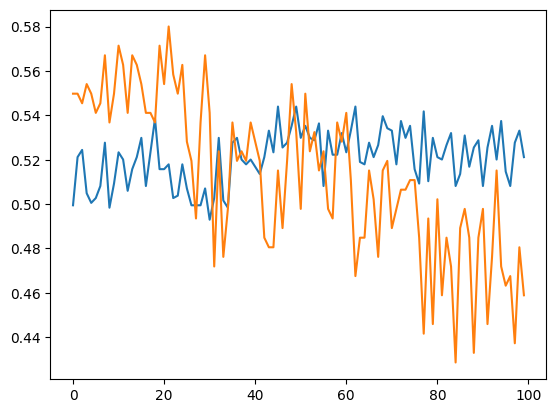

In [37]:
import matplotlib.pyplot as plt
# plt.plot(train_loss, label='Train Loss')
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')

In [89]:
file_path = f'/Users/siddharth/Documents/Brainconnectivity/filt_features/eeg_data_sub7_features.mat'
data = scipy.io.loadmat(file_path)
relevant_keys = list(data.keys())[4:]
feature = np.stack([data[key] for key in relevant_keys], axis=-1)  # Shape: (num_trials, num_nodes, feature_dim)

In [90]:
# Reshape to (144 trials, 22*17=374 features)
X = np.reshape(feature, (144, -1))  # New shape: (144, 374)

In [91]:
i = 7
subject_name = f'A0{i}T'
raw = mne.io.read_raw_gdf(f'/Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/{subject_name}.gdf',
                        eog=['EOG-left', 'EOG-central', 'EOG-right'], preload=True)
raw.drop_channels(['EOG-left', 'EOG-central', 'EOG-right'])
raw.set_eeg_reference()
montage = mne.channels.make_standard_montage('standard_1020')  # Use 'standard_1020' or custom montage
raw.set_montage(montage)
events = mne.events_from_annotations(raw)
epoch = mne.Epochs(raw, events[0], event_id={'769': 7, '770': 8}, tmin=-1.5, tmax=6, on_missing='warn', preload=True)
labels = epoch.events[:, -1] - 7

Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A07T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 681070  =      0.000 ...  2724.280 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
(array([[     0,      0,      5],
       [     0,      0,      3],
       [ 27170,      0,      5],
       ...,
       [677534,      0,      7],
       [679093,      0,      6],
       [679593,      0,      9]]), {'1023': 1, '1072': 2, '276': 3, '277': 4, '32766': 5, '768': 6, '769': 7, '770': 8, '771': 9, '772': 10})
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped


In [75]:
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)

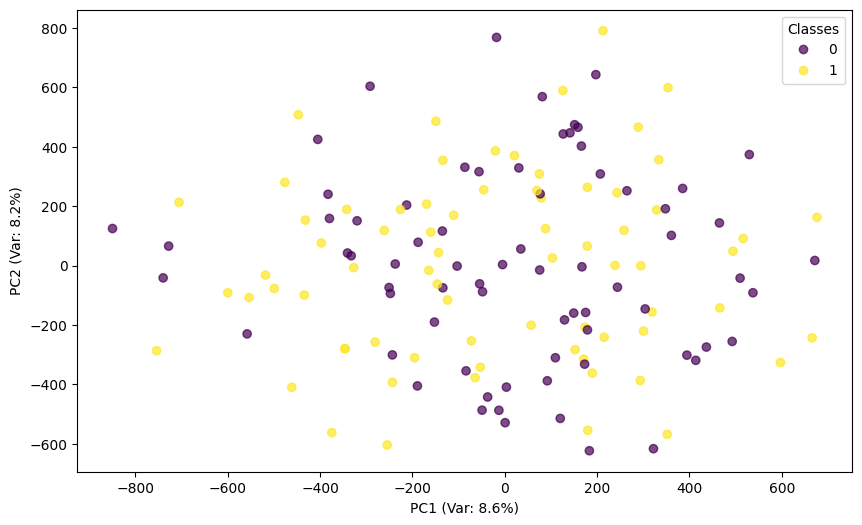

In [92]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', alpha=0.7)
plt.xlabel('PC1 (Var: {:.1f}%)'.format(pca.explained_variance_ratio_[0]*100))
plt.ylabel('PC2 (Var: {:.1f}%)'.format(pca.explained_variance_ratio_[1]*100))
plt.legend(*scatter.legend_elements(), title="Classes")
plt.show()

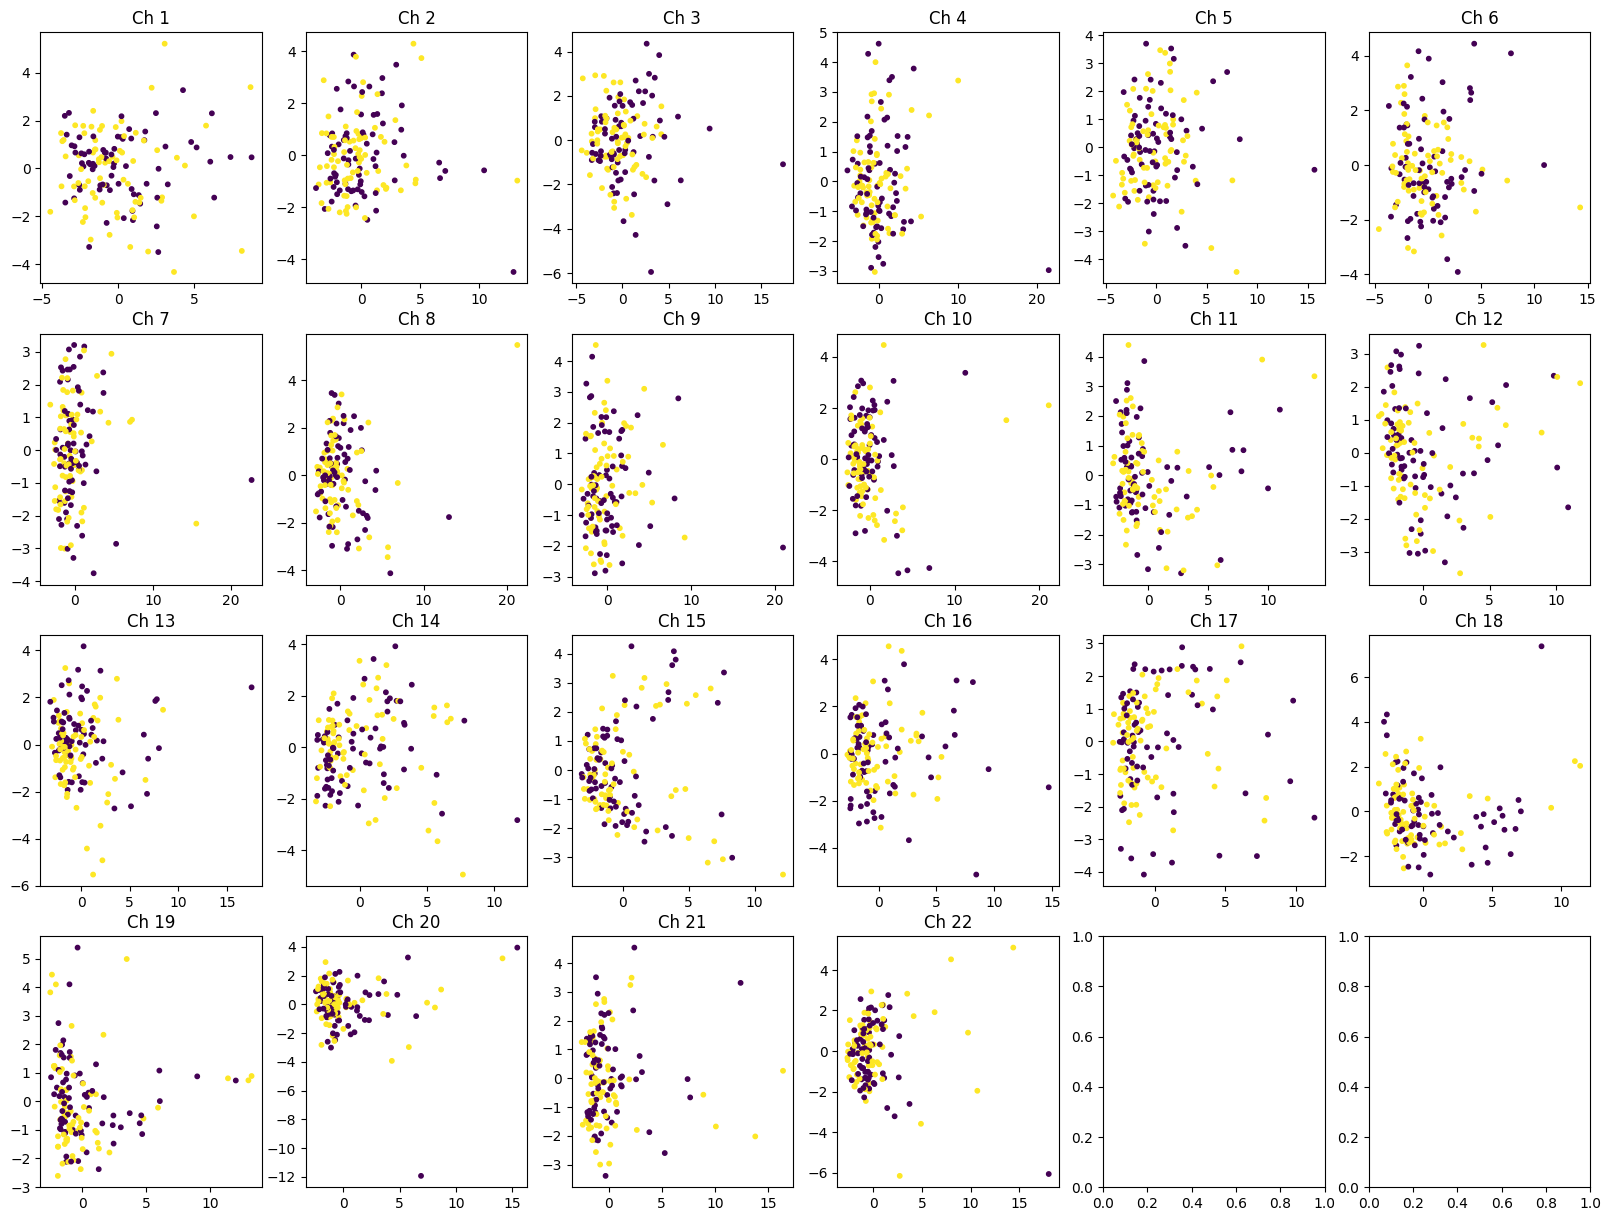

In [93]:
fig, axs = plt.subplots(4, 6, figsize=(20,15))  # For 22 channels (adjust grid)

for ch in range(22):
    ax = axs[ch//6, ch%6]
    ch_feature = feature[:, ch, :]  # (144,17)
    pca = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(ch_feature))
    ax.scatter(pca[:,0], pca[:,1], c=labels, cmap='viridis', s=10)
    ax.set_title(f'Ch {ch+1}')

MNE Feature Extraction

In [24]:
from scipy.io import loadmat
import mne
import numpy as np

In [15]:
eeg_data = loadmat('/Users/siddharth/Documents/Brainconnectivity/Filt/eeg_data_sub2.mat')

In [17]:
i = 2
subject_name = f'A0{i}T'
raw = mne.io.read_raw_gdf(f'/Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/{subject_name}.gdf',
                        eog=['EOG-left', 'EOG-central', 'EOG-right'], preload=True)
raw.drop_channels(['EOG-left', 'EOG-central', 'EOG-right'])
raw.set_eeg_reference()
# montage = mne.channels.make_standard_montage('standard_1020')  # Use 'standard_1020' or custom montage
# raw.set_montage(montage)
events = mne.events_from_annotations(raw)
epoch = mne.Epochs(raw, events[0], event_id={'769': 7, '770': 8}, tmin=-1.5, tmax=6, on_missing='warn', preload=True)
labels = epoch.events[:, -1] - 7

Extracting EDF parameters from /Users/siddharth/Documents/Brainconnectivity/BCICIV_2a_gdf/A02T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG
Creating raw.info structure...
Reading 0 ... 677168  =      0.000 ...  2708.672 secs...


/opt/homebrew/Cellar/python@3.11/3.11.9/Frameworks/Python.framework/Versions/3.11/lib/python3.11/contextlib.py:144: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
Setting baseline interval to [-1.5, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 144 events and 1876 original time points ...
0 bad epochs dropped


In [18]:
eeg_data['eeg_data'].shape

(144, 22, 751)

In [51]:
from mne.filter import filter_data

# Apply μ+β bandpass BEFORE CSP/features
eeg_filtered = filter_data(eeg_data['eeg_data'], sfreq=250, l_freq=8, h_freq=30,
                           method='fir', phase='zero-double', verbose=False)

In [52]:
tmin, tmax = 0.5, 2.5

In [ ]:
hjorth_activity, hjorth_mobility, hjorth_complexity = [], [], []

In [1]:
from mne.decoding import Vectorizer, Scaler
from mne_features.feature_extraction import FeatureExtractor
feature_list = [
    'pow_freq_bands',  # Explicit μ/β
    'wavelet_coef_energy', 
    'hjorth_complexity',
    'spect_corre',  # C3-C4, C3-Cz
]

extractor = FeatureExtractor(sfreq=250, selected_funcs=feature_list)
X_features = extractor.fit_transform(eeg_filtered[..., :int((tmax-tmin)*250)])  # Crop to ERD window

NameError: name 'eeg_filtered' is not defined

In [69]:
from mne.decoding import CSP
csp_window = eeg_filtered[..., int(0.5*250):int(2.5*250)]  # 0.5-2.5s
csp = CSP(n_components=4, reg='ledoit_wolf', log=True)  # Fewer components
X_csp = csp.fit_transform(csp_window, labels)

Computing rank from data with rank=None


    Using tolerance 5.9e-06 (2.2e-16 eps * 22 dim * 1.2e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.


In [70]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Combine and select
X_combined = np.hstack([X_features, X_csp])
selector = SelectKBest(mutual_info_classif, k=20)
X_selected = selector.fit_transform(X_combined, labels)

In [71]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__gamma': ['scale', 0.01, 0.1]
}

clf = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', class_weight='balanced')
)

gscv = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy')
gscv.fit(X_selected, labels)
print(f"Best SVM Accuracy: {gscv.best_score_:.2f}")

Best SVM Accuracy: 0.65


(Text(0.5, 0, 'Top Feature 1'), Text(0, 0.5, 'Top Feature 2'))

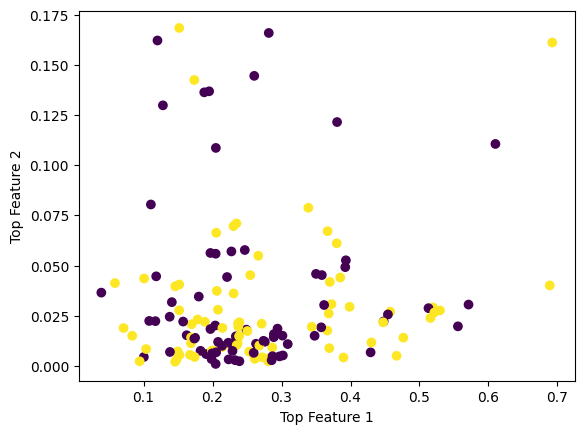

In [73]:
plt.scatter(X_selected[:,0], X_selected[:,1], c=labels)
plt.xlabel('Top Feature 1'), plt.ylabel('Top Feature 2')

In [77]:
X_selected.shape

(144, 20)

Verifying Temporal Filtering

    Using multitaper spectrum estimation with 7 DPSS windows


Text(0.5, 1.0, 'Power Spectral Density')

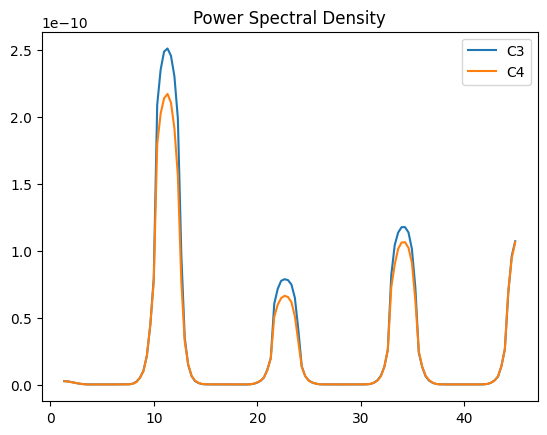

In [138]:
from mne import time_frequency

# Plot PSD for C3/C4 channels
plt.figure()
psd = time_frequency.psd_array_multitaper(eeg_data['eeg_data'][:, [0,1]], sfreq=250, fmin=1, fmax=45)
plt.plot(psd[1], psd[0].mean(axis=0).T)
plt.legend(['C3', 'C4'])
plt.title('Power Spectral Density')

In [141]:
from mne.time_frequency import tfr_multitaper

# Compute ERDS maps
tfr = tfr_multitaper(, freqs=np.arange(8,31), n_cycles=5, 
                     time_bandwidth=4, return_itc=False)
tfr.plot([0], baseline=(0,0.5), mode='percent', 
         title='ERDS Map (C3 - Left vs Right Trials)')

NOTE: tfr_multitaper() is a legacy function. New code should use .compute_tfr(method="multitaper").
inst is Evoked, setting `average=False`


AttributeError: 'numpy.ndarray' object has no attribute 'compute_tfr'

In [99]:
# Rebuild features to be channel-wise
# --------------------------------------------------
from mne_features.feature_extraction import FeatureExtractor

# Original data shape: (144 trials, 22 channels, 751 time points)
# eeg_data = np.random.rand(144, 22, 751)  # Your actual data here

# Extract features PER CHANNEL
feature_list = [
    'mean',  # 1 feature per channel
    'variance',  # 1 feature
    'pow_freq_bands',  # 2 features
    'hjorth_complexity',  # 1 feature
    'wavelet_coef_energy'  # 4 features
]

extractor = FeatureExtractor(sfreq=250, selected_funcs=feature_list, n_jobs=-1)
X_features = extractor.fit_transform(eeg_data['eeg_data'])  # Shape: (144, 22*9=198)

# Reshape to (trials, channels, features)
X_nodes = X_features.reshape(144, 22, 14)  # 9 features per channel

In [100]:
from sklearn.feature_selection import SelectKBest

X_flat = X_nodes.reshape(-1, 14)
selector = SelectKBest(k=5)  # Select top 5 features per channel
X_selected = selector.fit_transform(X_flat, np.repeat(labels, 22))

# Reshape back to (144, 22, 5)
X_nodes = X_selected.reshape(144, 22, 5)

In [122]:
from torch_geometric.data import Dataset, Data

class BCI2aGraph(Dataset):
    def __init__(self, X_nodes, labels):
        super().__init__()
        self.data_list = []
        
        # Create one Data object per trial
        for i in range(len(labels)):
            data = Data(
                x=torch.tensor(X_nodes[i], dtype=torch.float32),  # [22, 5]
                edge_index=self.create_edges(),  # [2, 231]
                y=torch.tensor(labels[i], dtype=torch.long)  # Scalar
            )
            self.data_list.append(data)
    
    def create_edges(self):
        return torch.combinations(torch.arange(22), 2).t().contiguous()
    
    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        return self.data_list[idx]

    def get(self, idx):
        return self.data_list[idx]
    
dataset = BCI2aGraph(X_nodes, labels)

In [102]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, TopKPooling, global_mean_pool

class EEGGNN(torch.nn.Module):
    def __init__(self, num_features=5, num_classes=2):
        super().__init__()
        
        # Dynamic edge weight learner
        self.edge_learner = torch.nn.Sequential(
            torch.nn.Linear(2*num_features + 1, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 1))
        
                # Graph attention layers
        self.gat1 = GATv2Conv(num_features, 32, edge_dim=1, heads=2)
        self.gat2 = GATv2Conv(32*2, 64, edge_dim=1, heads=1)
        self.res_lin = torch.nn.Linear(num_features, 64)  # Residual path
        
        # Adaptive pooling
        self.pool = TopKPooling(64, ratio=0.6)
        
        # Classifier
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(64, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, num_classes))
        
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        
        # Compute dynamic edge weights
        src, dest = edge_index
        edge_feat = torch.cat([x[src], x[dest], 
                            torch.norm(x[src]-x[dest], dim=1, keepdim=True)], dim=1)
        edge_weights = torch.sigmoid(self.edge_learner(edge_feat)).squeeze()
        
        # GNN forward pass
        x = F.elu(self.gat1(x, edge_index, edge_attr=edge_weights))
        x = F.elu(self.gat2(x, edge_index, edge_attr=edge_weights))
        x = x + self.res_lin(data.x)
        x, _, _, batch, _, _ = self.pool(x, edge_index, None, batch)
        
        # Readout and classification
        x = global_mean_pool(x, batch)
        return self.fc(x)

In [131]:
class EEGGNN(torch.nn.Module):
    def __init__(self, num_features=5, num_classes=2):
        super().__init__()
        
        # Temporal module
        self.temp_conv = torch.nn.Sequential(
            torch.nn.Linear(num_features, 32),
            torch.nn.GRU(32, 16, batch_first=True))
        
        # Edge learning with attention
        self.edge_attn = torch.nn.MultiheadAttention(16, 4, batch_first=True)
        
        # GNN components
        self.gat1 = GATv2Conv(16, 32, edge_dim=1, heads=2)
        self.gat2 = GATv2Conv(32*2, 64, edge_dim=1, heads=1)
        self.pool = TopKPooling(64, ratio=0.8)  # Less aggressive pooling
        
        # Classifier
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(64, 32),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(32, num_classes))
        
    def forward(self, data):
        # Temporal processing
        x_t = self.temp_conv(data.x.unsqueeze(0))[0].squeeze()  # [N,16]
        
        # Edge attention
        edge_feat, _ = self.edge_attn(x_t, x_t, x_t)
        edge_weights = torch.sigmoid(edge_feat.mean(dim=-1))
        
        # GNN
        x = F.elu(self.gat1(x_t, data.edge_index, edge_attr=edge_weights))
        x = F.elu(self.gat2(x, data.edge_index, edge_attr=edge_weights))
        x = global_mean_pool(x, data.batch)
        return self.fc(x)

In [132]:
from torch_geometric.loader import DataLoader
from sklearn.metrics import balanced_accuracy_score

model = EEGGNN(num_features=5)
# Hyperparameters
BATCH_SIZE = 2
LR = 1e-3
EPOCHS = 200

# Loss & Optimizer (with gradient clipping)
criterion = torch.nn.CrossEntropyLoss(
    weight=torch.tensor([0.6, 0.4])  # Handle class imbalance
)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, total_steps=EPOCHS*len(train_loader)
)   

# Initialize
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EEGGNN(num_features=5).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
criterion = torch.nn.CrossEntropyLoss()

# Split dataset
train_dataset = dataset[:100]
test_dataset = dataset[100:]
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [133]:
best_acc = 0
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = criterion(out, batch.y)
        loss += 0.1 * (edge_weights.norm() + model.gat1.lin_src.weight.norm())
        loss.backward()
        print(f'Grad norms - GAT1: {model.gat1.lin_src.weight.grad.norm():.2e} '
        f'Edge Learner: {model.edge_learner[0].weight.grad.norm():.2e}')
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    
    # Validation
    model.eval()
    correct = 0
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            pred = model(batch).argmax(dim=1)
            correct += (pred == batch.y).sum().item()
    
    acc = correct / len(test_dataset)
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), 'best_model.pth')
    
    print(f'Epoch {epoch+1:03d} | '
          f'Train Loss: {train_loss/len(train_loader):.4f} | '
          f'Test Acc: {acc:.2f}')

IndexError: The shape of the mask [462] at index 0 does not match the shape of the indexed tensor [44] at index 0